In [1]:
#!pip install "numpy<2.0" --force-reinstall
#!pip install astropy ccdproc astroalign

Loaded Master Dark: Master_Darsk_Stack.fits
Processing 22 files...

--- Visual Check for 3C273_Quasar_3C273_Typ_Qu_Quasar_3C273_c1_2026-03-16_21-20-38_600.00s_0003.fits ---


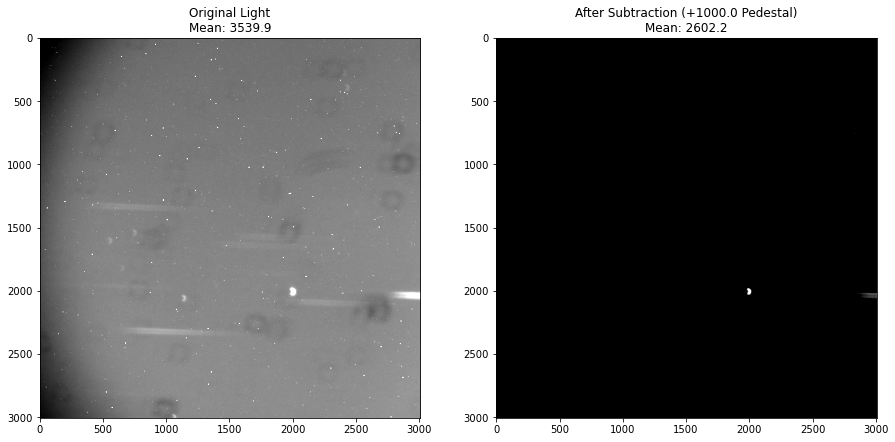

Pedestal Shift: -937.71 ADU

--- Step 1 Complete: Check 'Results' folder for subtracted files ---


In [2]:
import os
import numpy as np
from astropy.io import fits
# These imports fix the NameError
from astropy.visualization import stretch, ZScaleInterval, ImageNormalize
import matplotlib.pyplot as plt

# 1. Setup Directories
dirs = {'lights': 'Lights', 'darks': 'Darks', 'results': 'Results'}
for d in dirs.values():
    if not os.path.exists(d): os.makedirs(d)

# 2. Load Master Dark
dark_files = [f for f in os.listdir(dirs['darks']) if f.lower().endswith(('.fits', '.fit'))]
if not dark_files:
    print("Error: No master dark found in 'Darks' folder.")
else:
    dark_path = os.path.join(dirs['darks'], dark_files[0]) # Fix: Grab first file
    with fits.open(dark_path) as hdul:
        master_dark = hdul[0].data.astype('float32')
    
    print(f"Loaded Master Dark: {dark_files[0]}")

    # 3. Process Lights with Pedestal
    pedestal = 1000.0
    light_files = [f for f in os.listdir(dirs['lights']) if f.lower().endswith(('.fits', '.fit'))]
    print(f"Processing {len(light_files)} files...")

    for i, filename in enumerate(light_files):
        raw_path = os.path.join(dirs['lights'], filename)
        with fits.open(raw_path) as hdul:
            light_data = hdul[0].data.astype('float32')
            header = hdul[0].header
            
            # MATH: (Light - Dark) + Pedestal
            subtracted = (light_data - master_dark) + pedestal
            subtracted[subtracted < 0] = 0
            
            # Save
            out_path = os.path.join(dirs['results'], f"sub_{filename}")
            fits.writeto(out_path, subtracted, header, overwrite=True)
            
            # 4. VISUAL CHECK (Run only for the first file)
            if i == 0:
                print(f"\n--- Visual Check for {filename} ---")
                fig, ax = plt.subplots(1, 2, figsize=(15, 7))
                
                # Auto-scale the brightness for display
                norm = ImageNormalize(light_data, interval=ZScaleInterval(), stretch=stretch.LinearStretch())
                
                ax[0].imshow(light_data, cmap='gray', norm=norm)
                ax[0].set_title(f"Original Light\nMean: {np.mean(light_data):.1f}")
                
                ax[1].imshow(subtracted, cmap='gray', norm=norm)
                ax[1].set_title(f"After Subtraction (+{pedestal} Pedestal)\nMean: {np.mean(subtracted):.1f}")
                
                plt.show()
                print(f"Pedestal Shift: {np.mean(subtracted) - np.mean(light_data):.2f} ADU")

    print("\n--- Step 1 Complete: Check 'Results' folder for subtracted files ---")


Testing Spectrum Eraser on: sub_3C273_Quasar_3C273_Typ_Qu_Quasar_3C273_c1_2026-03-17_00-29-27_600.00s_0018.fits


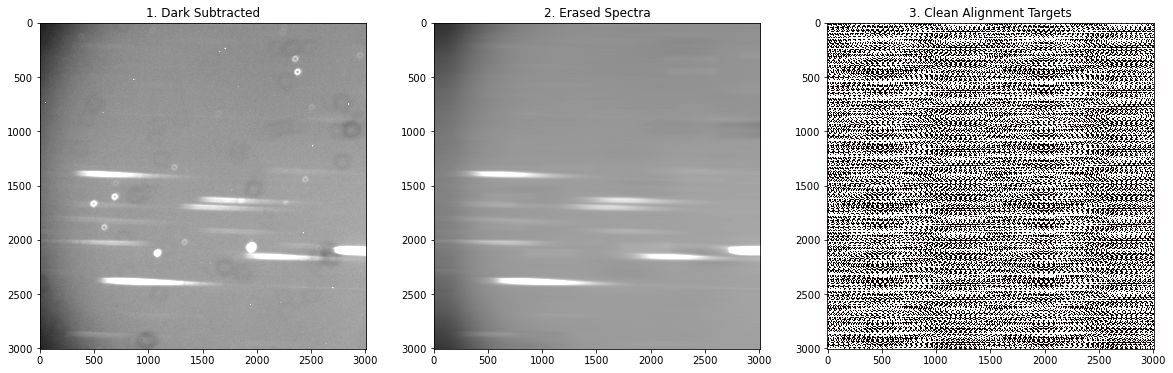

Does Pane 3 show clear stars and NO horizontal lines? (y/n):  n


In [19]:
import os
import numpy as np
from astropy.io import fits
from astropy.nddata import CCDData
import astroalign as aa
from ccdproc import Combiner
from scipy.ndimage import white_tophat, gaussian_filter, median_filter
import matplotlib.pyplot as plt
from astropy.visualization import stretch, ZScaleInterval, ImageNormalize

# --- 1. Settings ---
results_dir = 'Results'
target_timestamp = "2026-03-17_00-29-27"
sub_files = [f for f in os.listdir(results_dir) if f.startswith('sub_') and f.lower().endswith(('.fits', '.fit'))]
ref_filename = next((f for f in sub_files if target_timestamp in f), sub_files[-1])

def get_fits_data(hdul):
    """ Correctly finds image data in HDUList [0] or [1]. """
    for hdu in hdul:
        if hdu.data is not None and hdu.is_image:
            return hdu.data.astype('float32'), hdu.header
    raise ValueError("No image data found in FITS file.")

def prepare_for_alignment(data, debug=False):
    data_f = data.astype('float32')
    
    # 1. THE SPECTRUM ERASER 
    bg_model = median_filter(data_f, size=(1, 500)) 
    erased = data_f - bg_model
    
    # 2. THE TOP-HAT FILTER (Isolates donut stars)
    structure = np.ones((20, 20))
    tophat = white_tophat(erased, footprint=structure)
    
    # 3. STAR BOOSTER
    boosted = (tophat - np.mean(tophat)) / (np.std(tophat) + 1e-6)
    
    # 4. DONUT FILLER
    clean = gaussian_filter(boosted, sigma=4)
    
    # 5. AGGRESSIVE THRESHOLD (Keep top 2%)
    thresh = np.percentile(clean, 98) 
    clean[clean < thresh] = 0
    
    if debug:
        return clean.astype('float64'), bg_model
    return clean.astype('float64')

# --- 2. Visual Muster ---
print(f"Testing Spectrum Eraser on: {ref_filename}")
with fits.open(os.path.join(results_dir, ref_filename)) as hdul:
    ref_data, ref_header = get_fits_data(hdul)

ref_clean, spec_model = prepare_for_alignment(ref_data, debug=True)

fig, ax = plt.subplots(1, 3, figsize=(20, 6))
norm_orig = ImageNormalize(ref_data, interval=ZScaleInterval())
norm_clean = ImageNormalize(ref_clean, interval=ZScaleInterval())

ax[0].imshow(ref_data, cmap='gray', norm=norm_orig)
ax[0].set_title("1. Dark Subtracted")
ax[1].imshow(spec_model, cmap='gray', norm=norm_orig)
ax[1].set_title("2. Erased Spectra")
ax[2].imshow(ref_clean, cmap='hot', norm=norm_clean) 
ax[2].set_title("3. Clean Alignment Targets")
plt.show()

# --- 3. Alignment & Stacking ---
proceed = input("Does Pane 3 show clear stars and NO horizontal lines? (y/n): ")
if proceed.lower() == 'y':
    aligned_ccds = []
    print(f"\nAligning {len(sub_files)} files...")
    
    for filename in sub_files:
        path = os.path.join(results_dir, filename)
        with fits.open(path) as hdul:
            curr_data, curr_header = get_fits_data(hdul)

        if filename == ref_filename:
            aligned_ccds.append(CCDData(curr_data, unit='adu', header=curr_header))
            continue

        curr_clean = prepare_for_alignment(curr_data)
        try:
            # Use 'clean' for math, 'curr_data' for the actual result
            transf, (src, dst) = aa.find_transform(curr_clean, ref_clean)
            aligned_data = aa.apply_transform(transf, curr_data, ref_data)
            aligned_ccds.append(CCDData(aligned_data, unit='adu', header=curr_header))
            print(f"Aligned: {filename} ({len(src)} stars matched)")
        except Exception as e:
            print(f"Skipping {filename}: {e}")

    if len(aligned_ccds) > 1:
        print(f"\nStacking {len(aligned_ccds)} frames...")
        combiner = Combiner(aligned_ccds)
        stacked = combiner.median_combine()
        out_name = os.path.join(results_dir, f"Stacked_3C273_Final.fits")
        stacked.write(out_name, overwrite=True)
        print(f"SUCCESS: {out_name} created!")
